## imports

In [292]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [293]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel
import multiprocess
from ult import *

In [294]:
lick_color, attn_color='tab:orange', 'tab:blue'
sig_color='black'

In [295]:
modelname = 'varyrewardperoid2'
# training hyper params
epoch_size = 33333
n_epoch = 22
n_seed = 1
modeli = 0


no_episodes = 6666
epochtouse = 8

attcost = -1.6
facost = -50
p1p2 = np.array([.5, .7])
seed = 0
np.random.seed(seed)

vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
env_param = [0, None, attcost, .25, facost, 0, 0]

thismodel = f'seed_{seed}_{modelname}_{modeli}'

task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]}})
task.food_reward_list = food_reward_list
taskbelief = FuncBeliefModel(env=task, rng=1)
task.obs_certainity_possible = p1p2
model = PPO.load(f'ycstore/{thismodel}_epoch_{epochtouse}')
print(f'ycstore/{thismodel}_epoch_{epochtouse}')

ycstore/seed_0_varyrewardperoid2_0_epoch_8


# example trial

narrower. 
color choice for belief.
axis, sparse ticks.

In [296]:
episode = run_one_episode(task, taskbelief, model,
                          num_steps=1000)

# figs = plot_AF_episode(episode, task, model, nodes_from_zero = 40, time_steps_before_lick = 20)


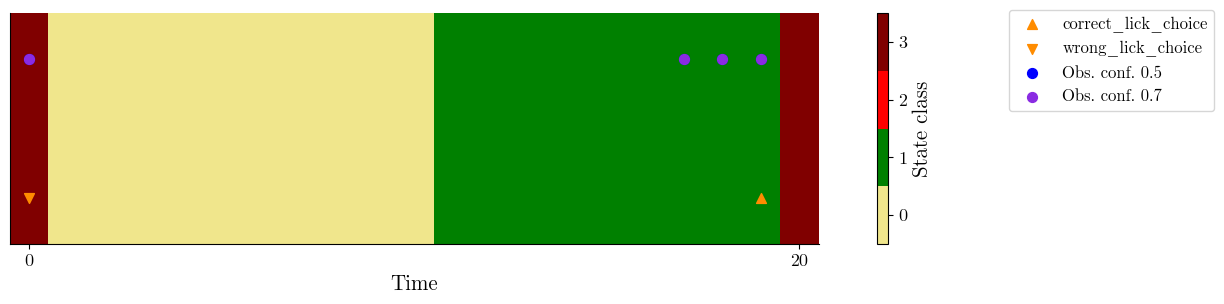

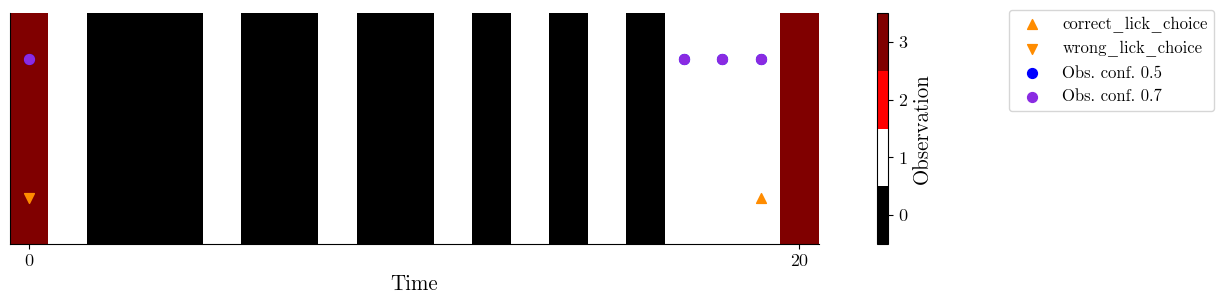

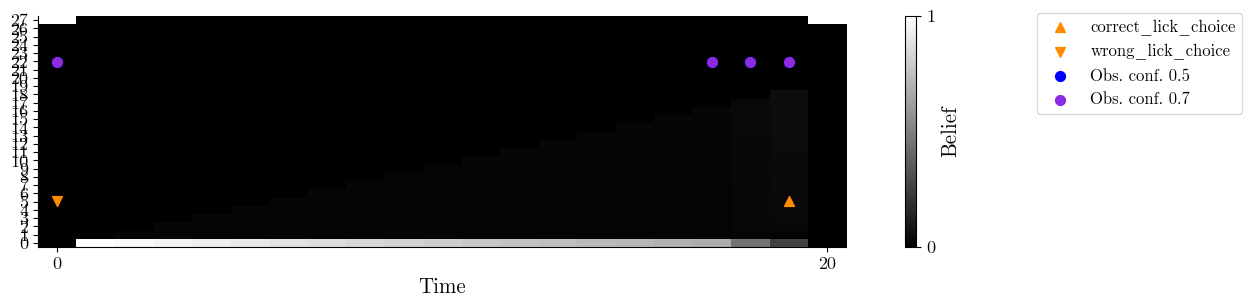

In [297]:
nodes_from_zero = 40
time_steps_before_lick = 20

obs_certainity_possible = task.obs_certainity_possible
dict_action_possible = task.dict_action_possible #{key: (lick_choice,attention_choice)}
no_attention_modes = task.no_attention_modes

#for episodic
no_signal_nodes = task.no_signal_nodes
no_penalty_nodes = task.no_penalty_nodes
no_ITI_nodes = task.no_ITI_nodes
no_nodes = task.no_nodes

licking_action_keys = [action_key for action_key in dict_action_possible if dict_action_possible[action_key][0] == 1]
attention_action_keys = []
for attention_choice in range(no_attention_modes):
    attention_action_keys.append([action_key for action_key in dict_action_possible if dict_action_possible[action_key][1] == attention_choice])

num_steps = episode['num_steps']
states = episode['states']
observations = episode['observations']
actions = episode['actions']
rewards = episode['rewards']
probs = episode['q_probs']
num_states = states.max()+1

attention_color_list = ['blue','blueviolet','indigo','magenta','darkcyan','cyan']

offset_actions = np.vstack((actions, [0,0]))
offset_rewards = np.append(rewards, 0) #offset actions to match time steps, as it looks like the rewards at last time step is not computed.

correct_lick_choice_idxs = list(map(lambda action_choice: True if action_choice[0] == 1 else False, offset_actions))&(offset_rewards>=0)
wrong_lick_choice_idxs = list(map(lambda action_choice: True if action_choice[0] == 1 else False, offset_actions))&(offset_rewards<0)
attention_choice_idxs = []
for attention_choice in range(no_attention_modes):

    attention_choice_idxs.append(list(map(lambda action_choice: True if action_choice[1] == 1 else False, offset_actions)))
env_plotter = PlotHelper(num_steps, no_attention_modes, correct_lick_choice_idxs, wrong_lick_choice_idxs, attention_choice_idxs, obs_certainity_possible, num_states)    
figs = []

state_classes = np.array([[assign_state_class(true_state, no_signal_nodes, no_penalty_nodes)] for true_state in states.flatten()])
fig = env_plotter.make_episode_plot(plot_variable = state_classes, label = 'State class', feature_color_list = ['khaki','green','red','maroon'], attention_color_list = attention_color_list)
figs.append(fig)
fig = env_plotter.make_episode_plot(plot_variable = observations, label = 'Observation', feature_color_list = ['black','white','red','maroon'], attention_color_list = attention_color_list)
figs.append(fig)
fig = env_plotter.make_episode_plot(plot_variable = probs, label = 'Belief', for_belief = True, attention_color_list = attention_color_list)    
figs.append(fig)

In [298]:


activations_list = []
for belief in episode['beliefs'][:-1]: #Last belief is not used for action
    activations_list.append(find_activation(model, belief).numpy())
for i,f in enumerate(figs):
    quicksave(f'episode{i}', modelname,fig=f)


att_probs, lick_probs, noise_probs, time = get_att_lick_probs_new(episode, model)

att=np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0]
lick= episode['actions'][-1][0] == 1



webf NOT subset; don't know how to subset; dropped
webf NOT subset; don't know how to subset; dropped
webf NOT subset; don't know how to subset; dropped


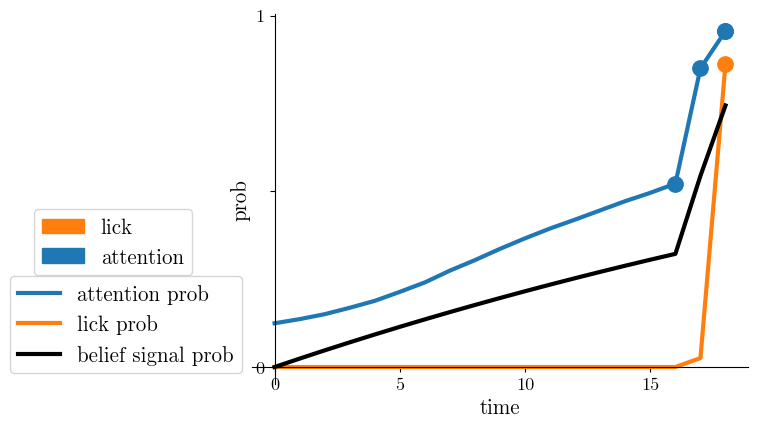

In [301]:
att_probs, lick_probs, noise_probs, time = get_att_lick_probs_new(
    episode, model)

att = np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[
    0]-1  # remove the start iti
lick = episode['actions'][-1][0] == 1


fig = plt.figure()
plt.plot(att_probs, label='attention prob', color=attn_color, linewidth=3)
plt.scatter(np.array(list(range(len(att_probs))))[att], np.array(
    att_probs)[att], color=attn_color, marker='o', s=122)

plt.plot(lick_probs, label='lick prob', color=lick_color, linewidth=3)
if lick:
    plt.scatter(len(lick_probs)-1,
                lick_probs[-1], color=lick_color, marker='o', s=122)

plt.plot([1-noise_prob for noise_prob in noise_probs],
         label='belief signal prob', color=sig_color, linewidth=3)
         
ax = plt.gca()
centerax(ax)
plt.yticks([0, .5, 1], ['0', '', '1'])
plt.xticks([0, 5, 10, 15])
plt.xlabel('time')
plt.ylabel('prob')


# Create Patch objects for the custom legend
lickdot = Patch(color=lick_color, label='lick')
attdot = Patch(color=attn_color, label='attention')
extra_legend = plt.legend(
    handles=[lickdot, attdot], bbox_to_anchor=(-0.1, 0.5), frameon=True)

ax.add_artist(extra_legend)
quickleg(ax)

plt.show()

# quicksave('episode curve', modelname,fig=fig)